In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

from tracking.base import *
from tracking.ctvr_ekf import CTVR_EKF
from tracking.ctvr_ukf import CTVR_UKF
from tracking.ctvr_pf import CTVR_PF
from tracking.ctvr_rbpf import CTVR_RBPF
from tracking.singer_ekf import SINGER_EKF

# Motion Model 1
## Coordinated Turn with Velocity and Rate (CTVR)

- position (x,y)
- velocity (v)
- heading (theta) , define y direction as heading 0
- yaw rate (omega)

state = [x, y, v, theta, omega]

#### state update
    state[n+1] = f(x[n], y[n], v[n], theta[n], omega[n]) + vk 

v[n+1] = v[n]

omega[n+1] = omega[n]

theta[n+1] = theta[n] + omega[n]*dt


##### lets find the circle we are travelling along!

 we start at x[n], y[n]

 circle radius is...

 circumference = time to rotate 2pi radians * linear velocity!

omega rad/s  -> 1/omega (s/rad) * 2pi (rad) = 2pi/omega = time to rotate 2pi

2pi*V/omega = Circumference = 2pi R -> R = V/omega





x[n+1] = x[n] + v[n] * sin(0.5*(theta[n+1] - theta[n])) * dt 

y[n+1] = x[n] + v[n] * cos(0.5*(theta[n+1] - theta[n])) * dt


In [2]:
class CTVR_State:
    def __init__(self, pos, vel, theta, omega):
        self.pos = pos
        self.vel = vel
        self.theta = theta
        self.omega = omega

    def vec(self):
        return np.array([self.pos[0], self.pos[1], self.vel, self.theta, self.omega])

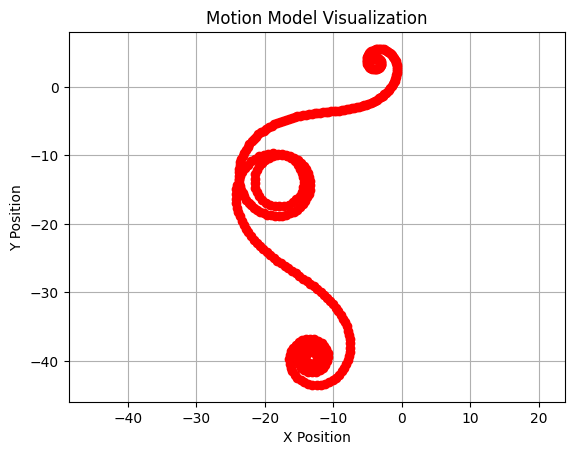

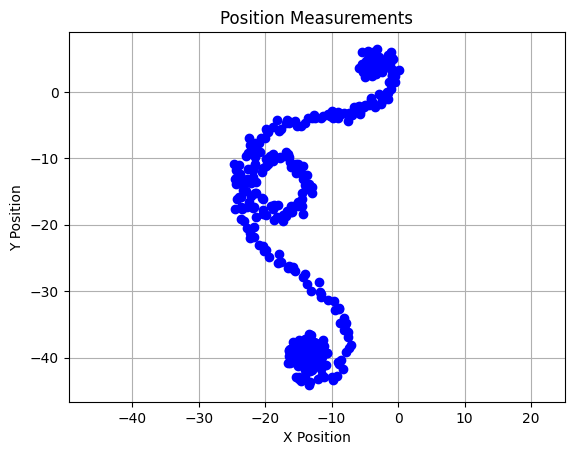

In [3]:
N = 400
DT = 0.1
NOISE = 1.0

class state:
    def __init__(self, pos, vel, theta, omega):
        self.pos = pos
        self.vel = vel
        self.theta = theta
        self.omega = omega

    def time_update(self, dt):
        x = self.pos[0]
        y = self.pos[1]

        if abs(self.omega) < 1e-6:
            x += self.vel*np.sin(self.theta)*dt
            y += self.vel*np.cos(self.theta)*dt
        else:    
            x += (self.vel / self.omega)*(np.cos(self.theta) - np.cos(self.theta + self.omega*dt))
            y += -(self.vel / self.omega)*(np.sin(self.theta) - np.sin(self.theta + self.omega*dt))
            
        self.theta += self.omega*dt
        self.pos = np.array([x, y])
        return

    def input_update(self, vel, omega):
        self.vel = vel
        self.omega = omega
        pass



state = state(pos=np.array([-4,4]),
              vel=1,
              theta=np.deg2rad(45),
              omega=2.0)


plt.figure()
plt.plot(state.pos[0], state.pos[1], 'ro')
pos_meas = [state.pos + 1*np.random.normal(0, 0.5, size=2)]
pos_true = [state.pos.copy()]

for i in range(N):

    state.time_update(DT)

    if i < 200:
        dv = 0.03
        dw = -0.02
    else:
        dv = -0.01
        dw = 0.04
    state.input_update(vel=state.vel+dv, omega=state.omega+dw)

    plt.plot(state.pos[0], state.pos[1], 'ro')

    pos_meas.append(state.pos + NOISE*np.random.normal(0, 0.5, size=2))
    pos_true.append(state.pos.copy())


plt.title('Motion Model Visualization')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.grid()
plt.axis('equal')
plt.show()


plt.figure()
plt.plot([pos[0] for pos in pos_meas], [pos[1] for pos in pos_meas], 'bo', label='Position Measurements')
plt.title('Position Measurements')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.grid()
plt.axis('equal')
plt.show()


# Tracking Test of Motion Model 1

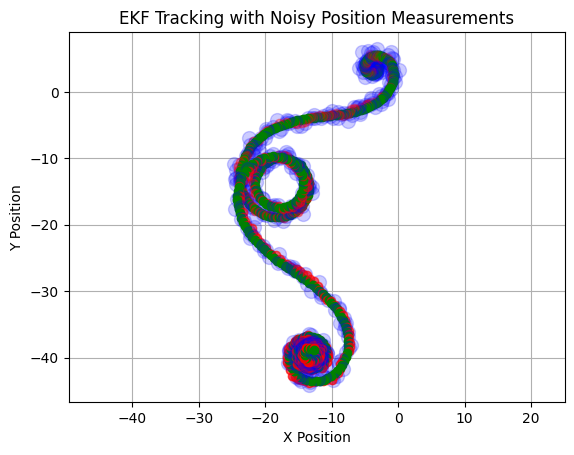

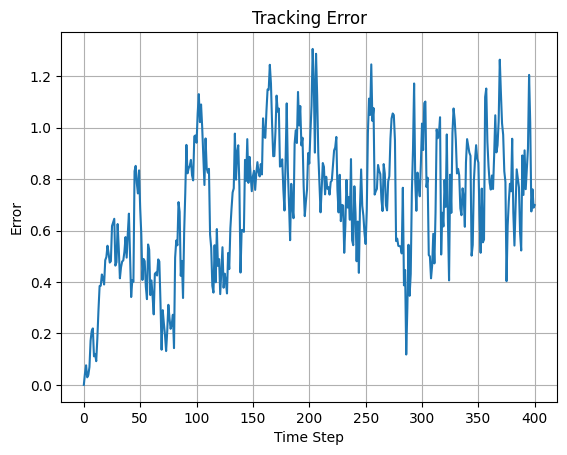

2 sigma (95.45%): 1.1108
3 sigma (99.73%): 1.2855


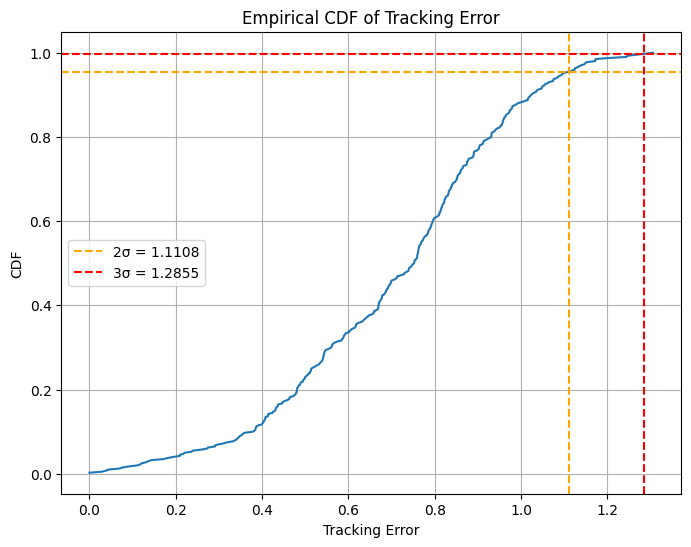

In [4]:

state = CTVR_State(pos=np.array([-4,4]),
              vel=1,
              theta=np.deg2rad(45),
              omega=2.0).vec()

ekf = CTVR_EKF(state)

plt.figure()
plt.plot(state[0], state[1], 'ro')

pos_track = [state[0:2]]

for i in range(N):

    ekf.predict(DT)

    # measure
    measurement = pos_meas[i]

    ekf.update(measurement)
    state = ekf.get_state()


    plt.plot(pos_meas[i][0], pos_meas[i][1], 'bo', alpha=0.2, markersize=10)
    plt.plot(state[0], state[1], 'ro', alpha=0.1+0.002*i)
    plt.plot(pos_true[i][0], pos_true[i][1], 'go')
    pos_track.append(state[0:2])

plt.axis('equal')
plt.title('EKF Tracking with Noisy Position Measurements')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.grid()
plt.show()


plt.figure()
track_error = [np.linalg.norm(np.array(pos_track[i]) - np.array(pos_true[i])) for i in range(len(pos_track))]
plt.plot(track_error)
plt.title('Tracking Error')
plt.xlabel('Time Step')
plt.ylabel('Error')
plt.grid()
plt.show()

sorted_errors = np.sort(track_error)
cdf = np.arange(1, len(sorted_errors)+1) / len(sorted_errors)

sigma2 = np.percentile(track_error, 95.45)
sigma3 = np.percentile(track_error, 99.73)

print(f"2 sigma (95.45%): {sigma2:.4f}")
print(f"3 sigma (99.73%): {sigma3:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(sorted_errors, cdf)
plt.axvline(sigma2, color='orange', linestyle='--', label=f'2σ = {sigma2:.4f}')
plt.axhline(0.9545, color='orange', linestyle='--')
plt.axvline(sigma3, color='red', linestyle='--', label=f'3σ = {sigma3:.4f}')
plt.axhline(0.9973, color='red', linestyle='--')
plt.title('Empirical CDF of Tracking Error')
plt.xlabel('Tracking Error')
plt.ylabel('CDF')
plt.legend()
plt.grid()
plt.show()


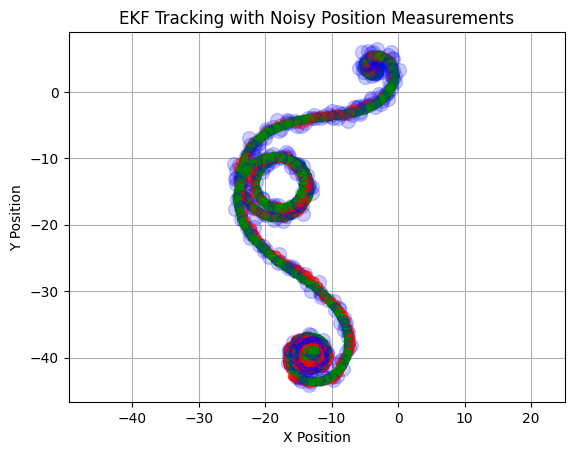

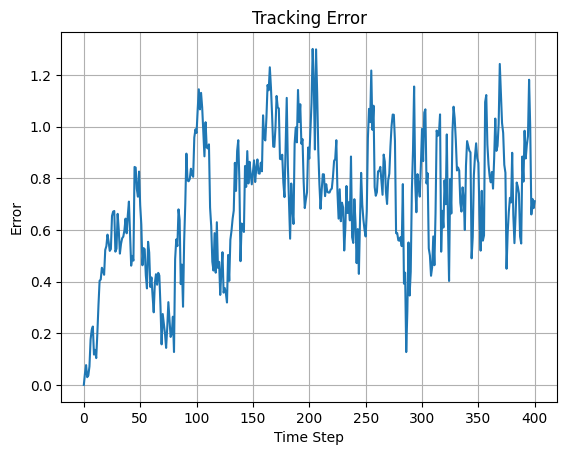

2 sigma (95.45%): 1.1082
3 sigma (99.73%): 1.2947


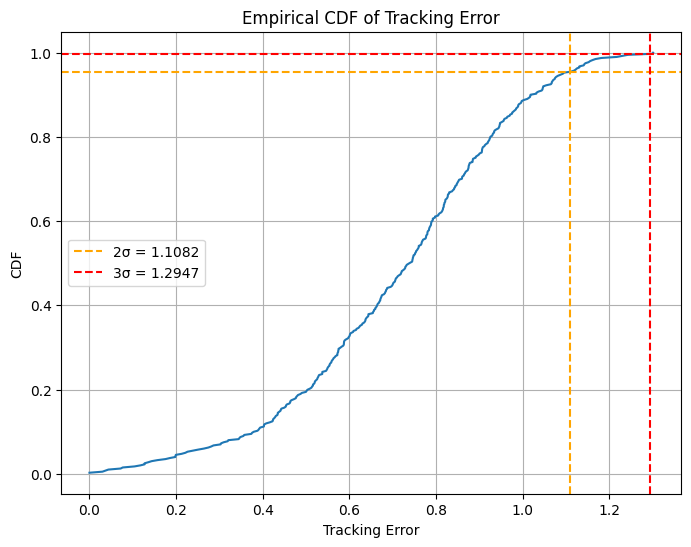

In [ ]:
state = CTVR_State(pos=np.array([-4,4]),
              vel=1,
              theta=np.deg2rad(45),
              omega=2.0).vec()

ekf = CTVR_UKF(state)

plt.figure()
plt.plot(state[0], state[1], 'ro')

pos_track = [state[0:2]]

for i in range(N):

    ekf.predict(DT)

    # measure
    measurement = pos_meas[i]

    ekf.update(measurement)
    state = ekf.get_state()


    plt.plot(pos_meas[i][0], pos_meas[i][1], 'bo', alpha=0.2, markersize=10)
    plt.plot(state[0], state[1], 'ro', alpha=0.1+0.002*i)
    plt.plot(pos_true[i][0], pos_true[i][1], 'go')
    pos_track.append(state[0:2])

plt.axis('equal')
plt.title('UKF Tracking with Noisy Position Measurements')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.grid()
plt.show()


plt.figure()
track_error = [np.linalg.norm(np.array(pos_track[i]) - np.array(pos_true[i])) for i in range(len(pos_track))]
plt.plot(track_error)
plt.title('Tracking Error')
plt.xlabel('Time Step')
plt.ylabel('Error')
plt.grid()
plt.show()

sorted_errors = np.sort(track_error)
cdf = np.arange(1, len(sorted_errors)+1) / len(sorted_errors)

sigma2 = np.percentile(track_error, 95.45)
sigma3 = np.percentile(track_error, 99.73)

print(f"2 sigma (95.45%): {sigma2:.4f}")
print(f"3 sigma (99.73%): {sigma3:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(sorted_errors, cdf)
plt.axvline(sigma2, color='orange', linestyle='--', label=f'2σ = {sigma2:.4f}')
plt.axhline(0.9545, color='orange', linestyle='--')
plt.axvline(sigma3, color='red', linestyle='--', label=f'3σ = {sigma3:.4f}')
plt.axhline(0.9973, color='red', linestyle='--')
plt.title('Empirical CDF of Tracking Error')
plt.xlabel('Tracking Error')
plt.ylabel('CDF')
plt.legend()
plt.grid()
plt.show()

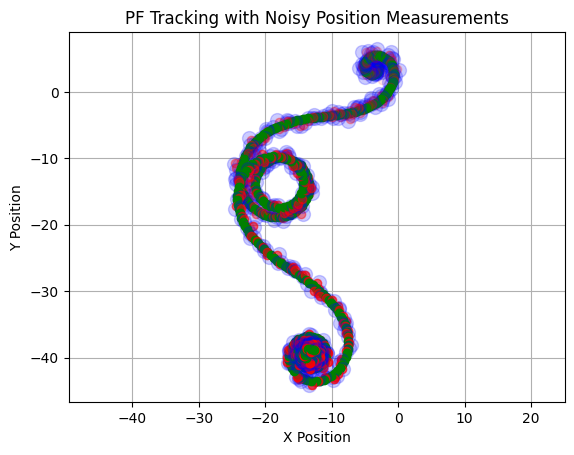

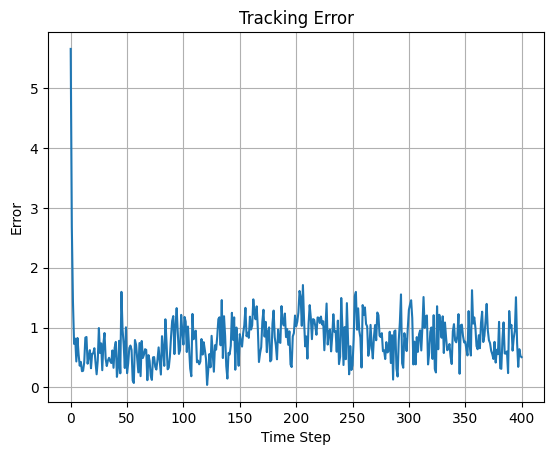

2 sigma (95.45%): 1.4000
3 sigma (99.73%): 2.6011


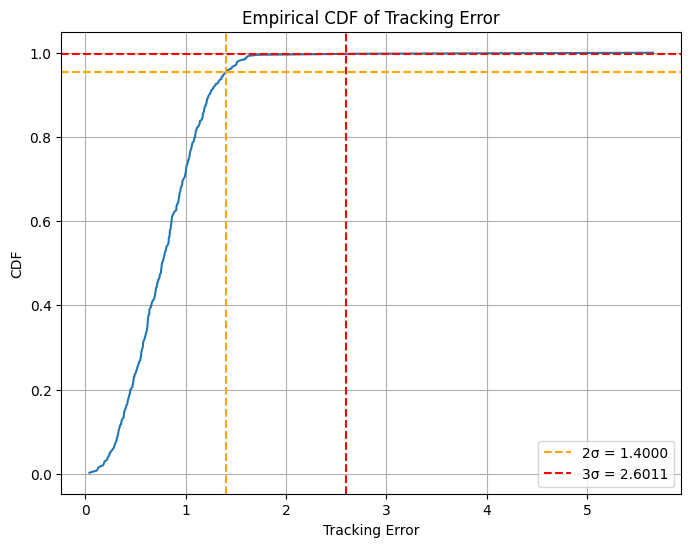

In [6]:
state = CTVR_State(pos=np.array([0,0]),
              vel=0,
              theta=np.deg2rad(0),
              omega=0.0).vec()

particles = np.random.multivariate_normal(mean=state, cov=np.eye(5)*1.0, size=100)

pf = CTVR_PF(particles, Q=np.eye(5)*0.3, R=np.eye(2)*0.25)

plt.figure()
# plt.plot(state[0], state[1], 'ro')

pos_track = [state[0:2]]

for i in range(N):
    measurement = pos_meas[i]

    # run particle filter
    state = pf.update(measurement, DT)

    # plt.plot(pf.weights, pf.particles[:,0])
    # plt.show()

    plt.plot(pos_meas[i][0], pos_meas[i][1], 'bo', alpha=0.2, markersize=10)
    plt.plot(state[0], state[1], 'ro', alpha=0.1+0.002*i)
    plt.plot(pos_true[i][0], pos_true[i][1], 'go')
    pos_track.append(state[0:2])

plt.axis('equal')
plt.title('PF Tracking with Noisy Position Measurements')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.grid()
plt.show()


plt.figure()
track_error = [np.linalg.norm(np.array(pos_track[i]) - np.array(pos_true[i])) for i in range(len(pos_track))]
plt.plot(track_error)
plt.title('Tracking Error')
plt.xlabel('Time Step')
plt.ylabel('Error')
plt.grid()
plt.show()

sorted_errors = np.sort(track_error)
cdf = np.arange(1, len(sorted_errors)+1) / len(sorted_errors)

sigma2 = np.percentile(track_error, 95.45)
sigma3 = np.percentile(track_error, 99.73)

print(f"2 sigma (95.45%): {sigma2:.4f}")
print(f"3 sigma (99.73%): {sigma3:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(sorted_errors, cdf)
plt.axvline(sigma2, color='orange', linestyle='--', label=f'2σ = {sigma2:.4f}')
plt.axhline(0.9545, color='orange', linestyle='--')
plt.axvline(sigma3, color='red', linestyle='--', label=f'3σ = {sigma3:.4f}')
plt.axhline(0.9973, color='red', linestyle='--')
plt.title('Empirical CDF of Tracking Error')
plt.xlabel('Tracking Error')
plt.ylabel('CDF')
plt.legend()
plt.grid()
plt.show()

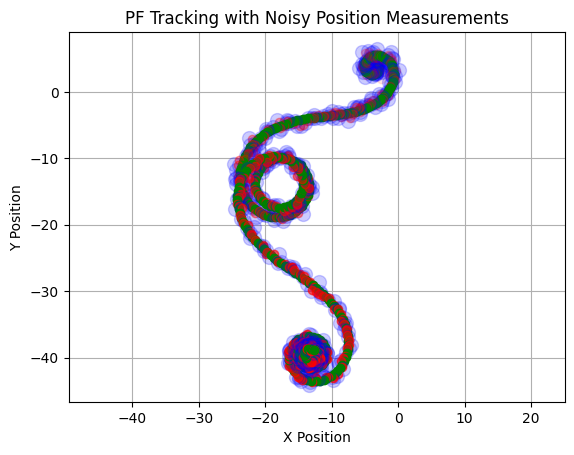

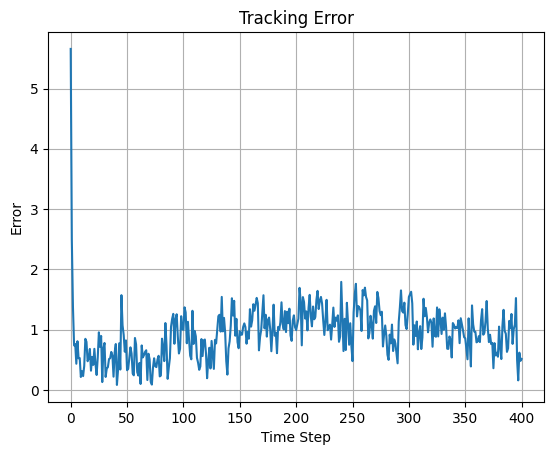

2 sigma (95.45%): 1.5428
3 sigma (99.73%): 2.4341


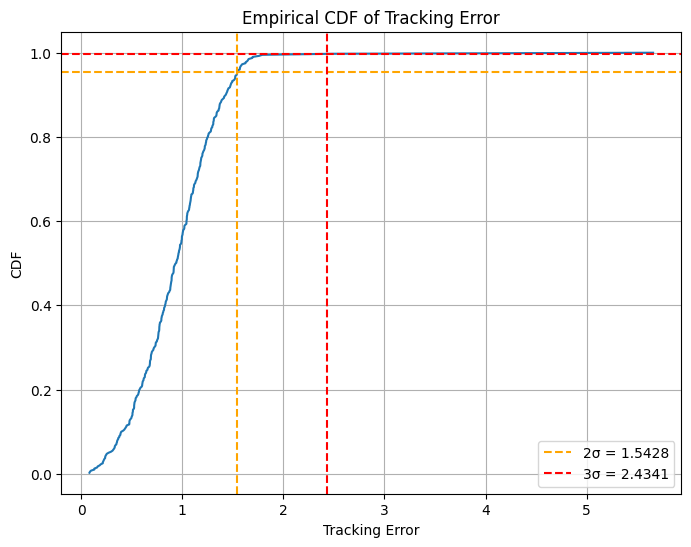

In [ ]:
# Rao-Blackwellized Particle Filter
# tracks non-linear state with particle filter
# tracks linear state with kalman filter

num_particles = 100

# x, y, w, v, dw, u_v, u_w, Pu, Pdw
# non-linear - x, y, w - tracked with PF
state_nl = np.array([0, 0, 0])

# linear - v, dw, u_v, u_w, P00, P01 P10, P11 - tracked with KF
state_l = np.array([0, 0, 0, 0, 0.1, 0.0, 0.0, 0.1])

state = np.concatenate((state_nl, state_l))
sampling_cov = np.block([
    [np.eye(len(state_nl))*2.0, np.zeros((len(state_nl), len(state_l)))],
    [np.zeros((len(state_l), len(state_nl))), np.zeros((len(state_l), len(state_l)))]
])

particles = np.random.multivariate_normal(mean=state, cov=sampling_cov, size=num_particles)


rbpf = CTVR_RBPF(particles)

plt.figure()
# plt.plot(state[0], state[1], 'ro')

pos_track = [state[0:2]]

for i in range(N):
    measurement = pos_meas[i]

    # run particle filter
    state = rbpf.update(measurement, DT)

    # plt.plot(rbpf.weights, rbpf.particles[:,0])
    # plt.show()

    plt.plot(pos_meas[i][0], pos_meas[i][1], 'bo', alpha=0.2, markersize=10)
    plt.plot(state[0], state[1], 'ro', alpha=0.1+0.002*i)
    plt.plot(pos_true[i][0], pos_true[i][1], 'go')
    pos_track.append(state[0:2])

plt.axis('equal')
plt.title('RBPF Tracking with Noisy Position Measurements')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.grid()
plt.show()


plt.figure()
track_error = [np.linalg.norm(np.array(pos_track[i]) - np.array(pos_true[i])) for i in range(len(pos_track))]
plt.plot(track_error)
plt.title('Tracking Error')
plt.xlabel('Time Step')
plt.ylabel('Error')
plt.grid()
plt.show()

sorted_errors = np.sort(track_error)
cdf = np.arange(1, len(sorted_errors)+1) / len(sorted_errors)

sigma2 = np.percentile(track_error, 95.45)
sigma3 = np.percentile(track_error, 99.73)

print(f"2 sigma (95.45%): {sigma2:.4f}")
print(f"3 sigma (99.73%): {sigma3:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(sorted_errors, cdf)
plt.axvline(sigma2, color='orange', linestyle='--', label=f'2σ = {sigma2:.4f}')
plt.axhline(0.9545, color='orange', linestyle='--')
plt.axvline(sigma3, color='red', linestyle='--', label=f'3σ = {sigma3:.4f}')
plt.axhline(0.9973, color='red', linestyle='--')
plt.title('Empirical CDF of Tracking Error')
plt.xlabel('Tracking Error')
plt.ylabel('CDF')
plt.legend()
plt.grid()
plt.show()

# Motion Model 2
## Singer motion model

- position (x,y)
- velocity (dx/dt, dy/dy)
- acceleration (d^2x/dt^2, d^2y/dt^2)

state = [x, vx, ax, y, vy, ay]

#### state update
    state^[n+1] = Fn @ stage[n]

F = 
[[ 1  T  (αT−1+e^(−αT)) / α^2 ]
 [ 0  1     (1−e^(−αT)) / α   ]
 [ 0  0          e^(−αT)      ]]


#### measurement model

Y = [dt_s1, dt_s2, ..., dt_sn]

Y[n] = h(x[n], y[n]) + e_n

h_i(pos[n]) = (1/c) * norm(||pos - s_i|| - ||pos - s_ref||)

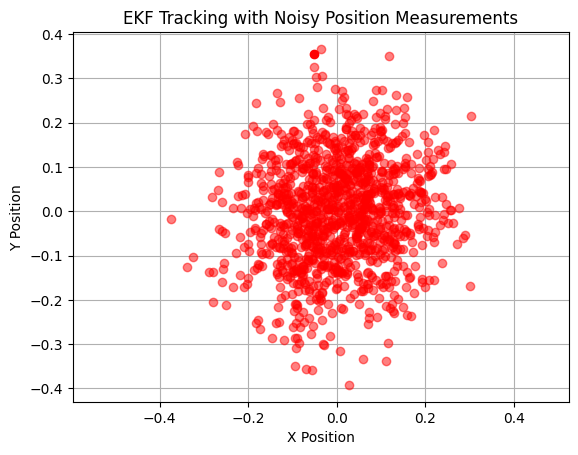

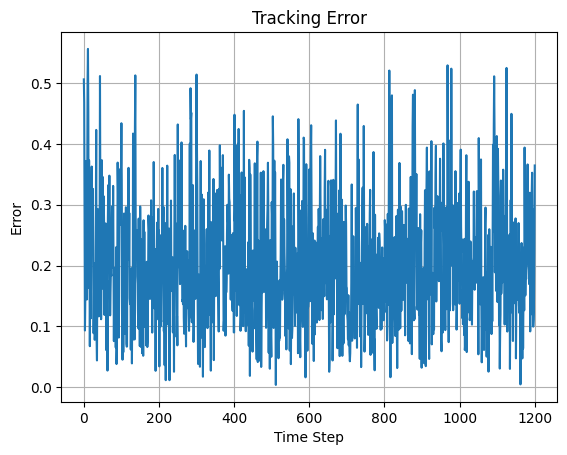

2 sigma (95.45%): 0.3977
3 sigma (99.73%): 0.5228


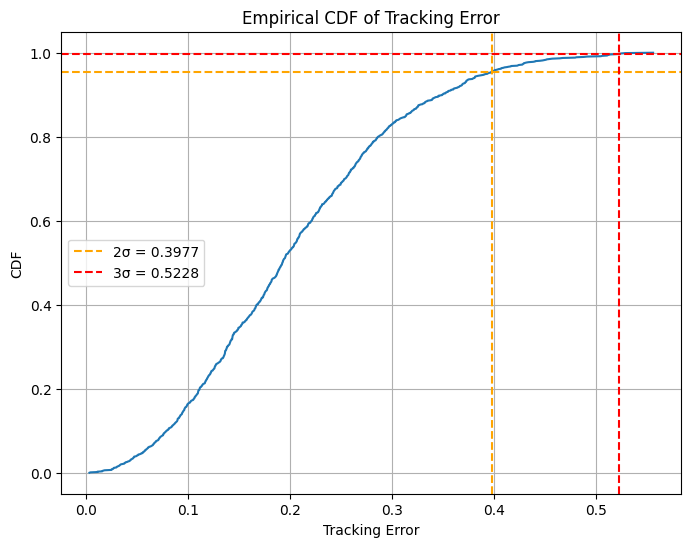

In [8]:
import numpy as np
import json
import os

local_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd()
cal_report_dir = local_dir + '/output/calibration_report.json'

with open(cal_report_dir, 'r') as f:
    calibration_report = json.load(f)

s_ref = [calibration_report['Sensor_0']['x'], calibration_report['Sensor_0']['y']]
s_1 = [calibration_report['Sensor_1']['x'], calibration_report['Sensor_1']['y']]
s_2 = [calibration_report['Sensor_2']['x'], calibration_report['Sensor_2']['y']]
s_3 = [calibration_report['Sensor_3']['x'], calibration_report['Sensor_3']['y']]

sref_toa = np.array(calibration_report['Sensor_0']['toa'])
s1_tdoa = np.array(calibration_report['Sensor_1']['toa']) - sref_toa
s2_tdoa = np.array(calibration_report['Sensor_2']['toa']) - sref_toa
s3_tdoa = np.array(calibration_report['Sensor_3']['toa']) - sref_toa

sref_var = calibration_report['Sensor_0']['pp_std'] ** 2
s1_var = calibration_report['Sensor_1']['pp_std'] ** 2
s2_var = calibration_report['Sensor_2']['pp_std'] ** 2
s3_var = calibration_report['Sensor_3']['pp_std'] ** 2

R = np.array([[s1_var + sref_var, sref_var, sref_var],
              [sref_var, s2_var + sref_var, sref_var],
              [sref_var, sref_var, s3_var + sref_var]])


state = np.array([[calibration_report['target_location'][0]['x'], 0.0, 0.0,
                   calibration_report['target_location'][0]['y'], 0.0, 0.0]]).T


ekf = SINGER_EKF(state, R, tau=0.5)
ekf.s_ref = s_ref
ekf.s_1 = s_1
ekf.s_2 = s_2
ekf.s_3 = s_3
ekf.c = 343.0

plt.figure()
plt.plot(state[0], state[3], 'ro')
pos_track = [[state[0], state[3]]]

for dt_s1, dt_s2, dt_s3 in zip(s1_tdoa, s2_tdoa, s3_tdoa):

    #predict
    ekf.predict(dt=0.5)

    measurement = np.array([[dt_s1, dt_s2, dt_s3]]).T
    ekf.update(measurement)

    state = ekf.get_state()

    pos_track.append([state[0], state[3]])
    plt.plot(state[0], state[3], 'ro', alpha=0.5)

plt.axis('equal')
plt.title('EKF Tracking with Noisy Position Measurements')
plt.xlabel('X Position')
plt.ylabel('Y Position')
plt.grid()
plt.show()


plt.figure()
track_error = [np.linalg.norm(np.array(pos_track[i]) - np.array([0.0, 0.0])) for i in range(len(pos_track))]
plt.plot(track_error)
plt.title('Tracking Error')
plt.xlabel('Time Step')
plt.ylabel('Error')
plt.grid()
plt.show()

sorted_errors = np.sort(track_error)
cdf = np.arange(1, len(sorted_errors)+1) / len(sorted_errors)

sigma2 = np.percentile(track_error, 95.45)
sigma3 = np.percentile(track_error, 99.73)

print(f"2 sigma (95.45%): {sigma2:.4f}")
print(f"3 sigma (99.73%): {sigma3:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(sorted_errors, cdf)
plt.axvline(sigma2, color='orange', linestyle='--', label=f'2σ = {sigma2:.4f}')
plt.axhline(0.9545, color='orange', linestyle='--')
plt.axvline(sigma3, color='red', linestyle='--', label=f'3σ = {sigma3:.4f}')
plt.axhline(0.9973, color='red', linestyle='--')
plt.title('Empirical CDF of Tracking Error')
plt.xlabel('Tracking Error')
plt.ylabel('CDF')
plt.legend()
plt.grid()
plt.show()